# Instructions

In this assignment, you will be working on **Smile Detection** using **YOLOv8** model, custom trained on 68 point facial landmarks dataset.

#### Task

You will have to complete the `smile_detector` function. In the function, you will receive an image and you have to write the logic for smile detection and return a boolean variable indicating whether the frame has a smiling person or not. 

We have provided the supporting code for keeping track of the smiling frames and we will use it to compare with the ground truth. If the percentage of overlap is high enough, you will obtain full marks.

Finally, we also write the output video in a avi file which you can download and see from the jupyter dashboard whether the smile is getting detected correctly.

You can see the output video to check whether the code detects smile or not and help to debug your code.

**You will have a total of 10 attempts.** This assignment carries 30 marks.

#### Some hints:

1. Find the lip and/or jaw coordinates using the facial landmarks.
1. For a person to be smiling, the ratio of width of the lip and the jaw width should be high.
1. Return `True` if a smile is detected, else return `False`.

#### Marks Distribution:
|Sections|Score|
|--------|-----|
|Implement `smile_detector` function| 30|


### Import the Ultralytics Library

In [2]:
# importing the necessary packages
import cv2
import os
import numpy as np
from ultralytics import YOLO  # Ensure you have the YOLO library installed
import matplotlib.pyplot as plt
%matplotlib inline

### YOLOv8 Model Loading:

In [3]:
# Load the YOLO model
MODEL_CKPT_PATH = "yolov8n_face_kpts.pt"
model = YOLO(MODEL_CKPT_PATH)

## TODO : Complete the smile detector function

You need to apply the face detector and shape_predictor to the input image to get the landmarks. 

Then, Use the landmarks and come up with a logic so that the smile is detected for each frame.

Finally, override the variable **`isSmiling`** to True if smile is detected.

You can explain your logic in the next cell.

### Solution Logic
Write your logic here

In [4]:
def get_keypoints(image_path):
    # Predict keypoints using the YOLO model
    results = model(image_path, verbose=False)
    if len(results) == 0 or results[0].keypoints is None:
        return []
    keypoints = results[0].keypoints.xy[0].cpu().numpy()
    pred_keypoints = [tuple(map(float, kp)) for kp in keypoints]
    return pred_keypoints

### Visualize Facial Keypoints:

Lets, visualize the keypoints on a face and extracted using the YOLOv8 facial landmark model.

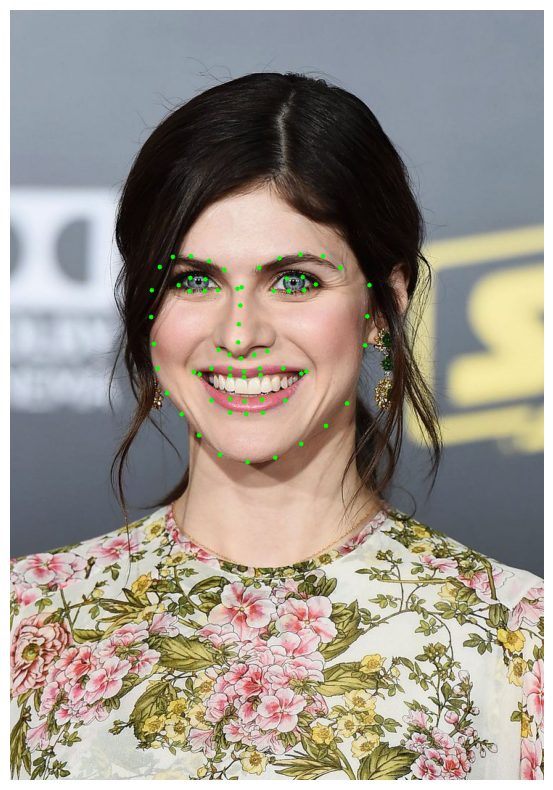

In [5]:
def visualize_keypoints(image_path, keypoints):
    image = cv2.imread(image_path)
    

    keypoints = [tuple(map(int, kp)) for kp in keypoints]
    

    for point in keypoints:
        cv2.circle(image, point, 3, (0, 255, 0), -1) 
    

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    

    plt.figure(figsize=(10,10))
    plt.imshow(image_rgb)
    plt.axis('off') 
    plt.show()

image_path = "Alexandra Daddario Smile.jpeg"
    

keypoints = get_keypoints(image_path)


visualize_keypoints(image_path, keypoints)


In [6]:
latest_smile_metrics = None

def compute_smile_metrics(imDlib):
    keypoints = get_keypoints(imDlib)
    mouth_width_ratio = 0.0
    corner_lift_ratio = 0.0
    eye_squint_ratio = 0.0
    isSmiling = False

    if len(keypoints) >= 55:
        keypoints_arr = np.array(keypoints)
        lip_left = keypoints_arr[48]
        lip_right = keypoints_arr[54]
        jaw_left = keypoints_arr[0]
        jaw_right = keypoints_arr[16]
        upper_lip_center = keypoints_arr[62]
        lower_lip_center = keypoints_arr[66]
        jaw_width = np.linalg.norm(jaw_right - jaw_left)
        if jaw_width > 0:
            lip_width = np.linalg.norm(lip_right - lip_left)
            mouth_width_ratio = lip_width / jaw_width

            mouth_center = (upper_lip_center + lower_lip_center) / 2.0
            corner_avg_y = 0.5 * (lip_left[1] + lip_right[1])
            center_y = mouth_center[1]
            corner_lift = center_y - corner_avg_y
            corner_lift_ratio = corner_lift / jaw_width

            if len(keypoints_arr) > 47:
                left_eye_open = abs(keypoints_arr[37][1] - keypoints_arr[41][1])
                right_eye_open = abs(keypoints_arr[43][1] - keypoints_arr[47][1])
                eye_squint_ratio = (left_eye_open + right_eye_open) / (2 * jaw_width)

            MOUTH_WIDTH_THRESHOLD = 0.34
            CORNER_LIFT_THRESHOLD = 0.01
            EYE_SQUINT_MAX = 0.07

            isSmiling = mouth_width_ratio > MOUTH_WIDTH_THRESHOLD and corner_lift_ratio > CORNER_LIFT_THRESHOLD
            if isSmiling and eye_squint_ratio > 0:
                if eye_squint_ratio > EYE_SQUINT_MAX:
                    isSmiling = False
    return keypoints, mouth_width_ratio, corner_lift_ratio, eye_squint_ratio, isSmiling

def smile_detector(imDlib):
    global latest_smile_metrics
    keypoints, mouth_width_ratio, corner_lift_ratio, eye_squint_ratio, isSmiling = compute_smile_metrics(imDlib)
    latest_smile_metrics = (keypoints, mouth_width_ratio, corner_lift_ratio, eye_squint_ratio, isSmiling)
    return isSmiling


## Main function

This is the supporting function that does the video loading and saving part. 

It also calls the smile_detector function and keeps track of the smile_frames variable which is used in grading.

In [8]:
capture = cv2.VideoCapture("smile.mp4")
if False == capture.isOpened():
    print("[ERROR] Video not opened properly")

frame_width = int(capture.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(capture.get(cv2.CAP_PROP_FRAME_HEIGHT))

smileDetectionOut = cv2.VideoWriter(
    "smileDetectionOutput.avi",
    cv2.VideoWriter_fourcc('M', 'J', 'P', 'G'),
    15,
    (frame_width, frame_height)
)

smileDetectionDebugOut = cv2.VideoWriter(
    "smileDetectionOutput_debug.avi",
    cv2.VideoWriter_fourcc('M', 'J', 'P', 'G'),
    15,
    (frame_width, frame_height)
)

frame_number = 0
smile_frames = []

while True:
    isGrabbed, frame = capture.read()
    if not isGrabbed:
        break

    debug_frame = frame.copy()
    image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    frame_has_smile = smile_detector(image)

    keypoints = []
    mouth_width_ratio = 0.0
    corner_lift_ratio = 0.0
    eye_squint_ratio = 0.0
    lip_open_ratio = 0.0

    if latest_smile_metrics is not None:
        keypoints, mouth_width_ratio, corner_lift_ratio, eye_squint_ratio, lip_open_ratio = latest_smile_metrics

    if len(keypoints) >= 67:
        keypoints_arr = np.array(keypoints)

        jaw_left = tuple(map(int, keypoints_arr[0]))
        jaw_right = tuple(map(int, keypoints_arr[16]))

        mouth_left = tuple(map(int, keypoints_arr[48]))
        mouth_right = tuple(map(int, keypoints_arr[54]))

        upper_lip_center = tuple(map(int, keypoints_arr[62]))
        lower_lip_center = tuple(map(int, keypoints_arr[66]))

        mouth_center = (
            (upper_lip_center[0] + lower_lip_center[0]) // 2,
            (upper_lip_center[1] + lower_lip_center[1]) // 2
        )

        MOUTH_WIDTH_THRESHOLD = 0.34
        CORNER_LIFT_THRESHOLD = 0.01
        EYE_SQUINT_MAX = 0.07
        LAUGH_OPEN_THRESHOLD = 0.06

        width_condition = mouth_width_ratio > MOUTH_WIDTH_THRESHOLD
        lift_condition = corner_lift_ratio > CORNER_LIFT_THRESHOLD
        squint_condition = True if eye_squint_ratio == 0 else eye_squint_ratio <= EYE_SQUINT_MAX
        laugh_condition = lip_open_ratio > LAUGH_OPEN_THRESHOLD

        neutral_color = (255, 255, 255)
        success_color = (0, 255, 0)
        fail_color = (0, 0, 255)
        laugh_color = (255, 0, 0)

        cv2.circle(debug_frame, jaw_left, 3, neutral_color, -1)
        cv2.circle(debug_frame, jaw_right, 3, neutral_color, -1)

        cv2.circle(debug_frame, mouth_left, 3, success_color if width_condition else fail_color, -1)
        cv2.circle(debug_frame, mouth_right, 3, success_color if width_condition else fail_color, -1)

        cv2.circle(debug_frame, mouth_center, 3, success_color if lift_condition else fail_color, -1)

        cv2.circle(debug_frame, upper_lip_center, 3, laugh_color if laugh_condition else neutral_color, -1)
        cv2.circle(debug_frame, lower_lip_center, 3, laugh_color if laugh_condition else neutral_color, -1)

        if len(keypoints_arr) > 47:
            left_eye_top = tuple(map(int, keypoints_arr[37]))
            left_eye_bottom = tuple(map(int, keypoints_arr[41]))
            right_eye_top = tuple(map(int, keypoints_arr[43]))
            right_eye_bottom = tuple(map(int, keypoints_arr[47]))

            eye_color = success_color if squint_condition else fail_color
            cv2.circle(debug_frame, left_eye_top, 3, eye_color, -1)
            cv2.circle(debug_frame, left_eye_bottom, 3, eye_color, -1)
            cv2.circle(debug_frame, right_eye_top, 3, eye_color, -1)
            cv2.circle(debug_frame, right_eye_bottom, 3, eye_color, -1)

        cv2.putText(
            debug_frame,
            f"mw={mouth_width_ratio:.2f}, cl={corner_lift_ratio:.3f}, sq={eye_squint_ratio:.3f}, lo={lip_open_ratio:.3f}",
            (20, 40),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (0, 255, 0),
            2,
            cv2.LINE_AA
        )
        cv2.putText(
            debug_frame,
            f"Smile={frame_has_smile}",
            (20, 70),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (0, 255, 0) if frame_has_smile else fail_color,
            2,
            cv2.LINE_AA
        )

    if frame_has_smile:
        cv2.putText(
            frame,
            "Smiling :)",
            (20, 80),
            cv2.FONT_HERSHEY_SIMPLEX,
            1.0,
            (0, 0, 255),
            2,
            cv2.LINE_AA
        )
        smile_frames.append(frame_number)

    if frame_number % 50 == 0:
        print('Processed {} frames'.format(frame_number))
        print("Smile detected in Frames: {}".format(smile_frames))

    smileDetectionOut.write(frame)
    smileDetectionDebugOut.write(debug_frame)

    frame_number += 1

capture.release()
smileDetectionOut.release()
smileDetectionDebugOut.release()

Processed 0 frames
Smile detected in Frames: [0]
Processed 50 frames
Smile detected in Frames: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50]
Processed 100 frames
Smile detected in Frames: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100]
Processed 150 frames
Smile detected in Frames: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 5

In [6]:
###
### AUTOGRADER TEST - DO NOT REMOVE
###
